# EPC Data Quality Audit: Camden, London
## 1. Data profiling

Source: Domestic Energy Performance Certificates, Camden, Jan 2012 - Jun 2026,
downloaded from get-energy-performance-data.communities.gov.uk (data not included
in repo due to licence).

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/camden_certificates.csv", low_memory=False)
print(df.shape)

(102185, 93)


In [2]:
df.head()

,certificate_number,address1,address2,address3,postcode,posttown,address,constituency,constituency_label,local_authority,...,walls_env_eff,wind_turbine_count,windows_description,windows_energy_eff,windows_env_eff,floor_env_eff,region,country,uprn,uprn_source
0,9637-2800-7390-9224-9051,"3, Agar Grove",NaN,NaN,NW1 9SL,LONDON,"3, Agar Grove",E14001290,Holborn and St Pancras,E09000007,...,Very Poor,0.0,Single glazed,Very Poor,Very Poor,NaN,E12000007,England,5055943.0,Energy Assessor
1,0060-2855-6531-9721-2181,"18, Brassey Road",NaN,NaN,NW6 2BE,LONDON,"18, Brassey Road",E14001265,Hampstead and Highgate,E09000007,...,Poor,0.0,Single glazed,Very Poor,Very Poor,NaN,E12000007,England,5003408.0,Energy Assessor
2,0125-3852-7281-9794-8445,7 Pickstock Court,155 Gray's Inn Road,NaN,WC1X 8UE,LONDON,"7 Pickstock Court, 155 Gray's Inn Road",E14001290,Holborn and St Pancras,E09000007,...,Very Good,0.0,High performance glazing,Very Good,Very Good,NaN,E12000007,England,5172370.0,Energy Assessor
3,0248-4906-7239-2994-6924,14b Agamemnon Road,NaN,NaN,NW6 1DY,LONDON,14b Agamemnon Road,E14001265,Hampstead and Highgate,E09000007,...,Very Poor,0.0,Single glazed,Very Poor,Very Poor,NaN,E12000007,England,NaN,NaN
4,0296-2873-6747-9592-3255,Rear Garden Flat,"61, Belsize Park Gardens",NaN,NW3 4JN,LONDON,"Rear Garden Flat, 61, Belsize Park Gardens",E14001265,Hampstead and Highgate,E09000007,...,Very Poor,0.0,Partial double glazing,Poor,Poor,NaN,E12000007,England,5115246.0,Energy Assessor


In [3]:
df.columns.tolist()

['certificate_number',
 'address1',
 'address2',
 'address3',
 'postcode',
 'posttown',
 'address',
 'constituency',
 'constituency_label',
 'local_authority',
 'local_authority_label',
 'built_form',
 'co2_emiss_curr_per_floor_area',
 'co2_emissions_current',
 'co2_emissions_potential',
 'construction_age_band',
 'current_energy_efficiency',
 'current_energy_rating',
 'energy_consumption_current',
 'energy_consumption_potential',
 'energy_tariff',
 'environment_impact_current',
 'environment_impact_potential',
 'extension_count',
 'fixed_lighting_outlets_count',
 'flat_storey_count',
 'flat_top_storey',
 'floor_description',
 'floor_energy_eff',
 'floor_height',
 'floor_level',
 'glazed_area',
 'glazed_type',
 'heat_loss_corridor',
 'heating_cost_current',
 'heating_cost_potential',
 'hot_water_cost_current',
 'hot_water_cost_potential',
 'hot_water_energy_eff',
 'hot_water_env_eff',
 'hotwater_description',
 'inspection_date',
 'lighting_cost_current',
 'lighting_cost_potential',
 'l

## 2. Completeness: missing values

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_pct.head(20)

sheating_env_eff            100.0
sheating_energy_eff         100.0
floor_env_eff                96.4
floor_energy_eff             96.4
secondheat_description       91.7
address3                     82.8
roof_env_eff                 63.2
roof_energy_eff              63.2
unheated_corridor_length     57.0
heat_loss_corridor           35.1
glazed_area                  34.9
glazed_type                  34.9
photo_supply                 28.5
mains_gas_flag               28.4
address2                     23.6
mechanical_ventilation       11.6
number_heated_rooms          11.6
solar_water_heating_flag     11.6
number_habitable_rooms       11.6
extension_count              11.6
dtype: float64

In [5]:
critical = ["uprn", "certificate_number", "postcode", "lodgement_date",
            "total_floor_area", "current_energy_rating", "construction_age_band", "tenure"]
missing_pct[critical].sort_values(ascending=False)

uprn                     9.1
tenure                   4.7
postcode                 0.0
certificate_number       0.0
lodgement_date           0.0
total_floor_area         0.0
current_energy_rating    0.0
construction_age_band    0.0
dtype: float64

### Findings: completeness

The core certificate fields are in good health: postcode, certificate_number,
lodgement_date, total_floor_area and current_energy_rating are all effectively
~100% complete across 102,185 records.

The gaps are concentrated where they hurt most:

- **9.1% of certificates (~9,300) have no UPRN**, the unique property identifier.
  These records cannot be reliably linked to a specific home, which undermines
  deduplication, property history tracking, and any address-level analysis.
- **11.6% of records (~11,900 homes) are missing basic property facts** such as
  number_habitable_rooms and number_heated_rooms. Five fields share this exact
  rate, suggesting a structural cause (e.g. certain assessment types omitting
  them) rather than random entry errors: to be investigated.
- **4.7% lack tenure** (owner-occupied vs rented), a gap with regulatory weight
  since minimum energy standards for rentals depend on knowing tenure.
- Two columns (sheating_env_eff, sheating_energy_eff) are 100% empty: dead
  columns carried in the extract.
- High missingness in address2 (23.6%) and address3 (82.8%) **is expected**, not a
  defect: most properties simply need fewer address lines.

## 3. Uniqueness: duplicate records

In [6]:
exact_dupes = df.duplicated().sum()
cert_dupes = df["certificate_number"].duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")
print(f"Duplicate certificate numbers: {cert_dupes}")

Exact duplicate rows: 0
Duplicate certificate numbers: 0


In [7]:
has_uprn = df[df["uprn"].notna()]
props = has_uprn["uprn"].nunique()
certs = len(has_uprn)
multi = has_uprn["uprn"].value_counts()
multi_props = (multi > 1).sum()
print(f"Certificates with a UPRN: {certs}")
print(f"Unique properties (UPRNs): {props}")
print(f"Properties with more than one certificate: {multi_props}")
print(f"Max certificates for a single property: {multi.max()}")

Certificates with a UPRN: 92883
Unique properties (UPRNs): 71513
Properties with more than one certificate: 17405
Max certificates for a single property: 69


In [8]:
top_uprn = multi.idxmax()
most_certified_uprn = has_uprn[has_uprn["uprn"] == top_uprn]
most_certified_uprn[["certificate_number", "address", "postcode", "lodgement_date",
          "current_energy_rating", "total_floor_area", "transaction_type"]].sort_values("lodgement_date")

,certificate_number,address,postcode,lodgement_date,current_energy_rating,total_floor_area,transaction_type
49539,0340-3442-0060-2707-2581,"E.3.1, 4 Lewis Cubitt Walk",N1C 4DY,2023-06-02,B,81,New dwelling
40163,7137-0736-4000-0472-5202,"E.4.1, 4 Lewis Cubitt Walk",N1C 4DY,2023-06-02,B,81,New dwelling
36414,0380-3162-3060-2407-6581,"E.11.3, 4 Lewis Cubitt Walk",N1C 4DY,2023-06-02,B,39,New dwelling
35398,0226-3005-1306-4847-7204,"E.11.1, 4 Lewis Cubitt Walk",N1C 4DY,2023-06-02,B,81,New dwelling
49366,0629-3005-4306-1387-4200,"E.11.5, 4 Lewis Cubitt Walk",N1C 4DY,2023-06-02,B,57,New dwelling
...,...,...,...,...,...,...,...
65418,3837-2430-1009-0877-5206,"E.13.4, 4 Lewis Cubitt Walk",N1C 4DY,2023-10-03,B,52,New dwelling
63253,9310-3787-6000-2407-2545,"E.13.5, 4 Lewis Cubitt Walk",N1C 4DY,2023-10-03,B,57,New dwelling
44666,6837-2430-1009-0807-5202,"E.14.4, 4 Lewis Cubitt Walk",N1C 4DY,2023-10-03,B,53,New dwelling
10324,0374-3905-3300-8367-4204,"E.13.3, 4 Lewis Cubitt Walk",N1C 4DY,2023-10-03,B,39,New dwelling


In [9]:
top10 = multi.head(10)
for uprn, count in top10.items():
    rows = has_uprn[has_uprn["uprn"] == uprn]
    print(f"UPRN {uprn}: {count} certs, {rows['address'].nunique()} distinct addresses, "
          f"postcode {rows['postcode'].iloc[0]}")

UPRN 5200862.0: 69 certs, 69 distinct addresses, postcode N1C 4DY
UPRN 5083282.0: 45 certs, 45 distinct addresses, postcode EC1R 5EG
UPRN 5082824.0: 32 certs, 30 distinct addresses, postcode WC1N 1DD
UPRN 5067987.0: 31 certs, 25 distinct addresses, postcode NW1 0DR
UPRN 5097188.0: 29 certs, 17 distinct addresses, postcode NW3 5JY
UPRN 5129025.0: 29 certs, 29 distinct addresses, postcode NW1 1DT
UPRN 5169012.0: 28 certs, 28 distinct addresses, postcode EC1N 8TE
UPRN 5169011.0: 28 certs, 28 distinct addresses, postcode EC1N 8TE
UPRN 5045735.0: 28 certs, 25 distinct addresses, postcode NW1 0DJ
UPRN 5169010.0: 28 certs, 28 distinct addresses, postcode EC1N 8TE


In [10]:
rebuild_case = has_uprn[has_uprn["uprn"] == 5097188.0]
rebuild_case[["address", "lodgement_date", "current_energy_rating",
              "total_floor_area", "transaction_type"]].sort_values(["address", "lodgement_date"])

,address,lodgement_date,current_energy_rating,total_floor_area,transaction_type
74422,"Flat 1, 11, Fitzjohns Avenue",2016-01-28,D,207,Marketed sale
70263,"Flat 1/A, 11, Fitzjohns Avenue",2016-01-28,D,23,Marketed sale
27389,"Flat 1/A, 11, Fitzjohns Avenue",2018-11-16,C,119,New dwelling
19450,"Flat 10/A, 11, Fitzjohns Avenue",2016-01-28,D,27,Marketed sale
91117,"Flat 10/A, 11, Fitzjohns Avenue",2018-11-16,C,49,New dwelling
83859,"Flat 11, 21, Fitzjohns Avenue",2018-07-16,E,150,Marketed sale
60871,"Flat 11/A, 11, Fitzjohns Avenue",2016-01-28,D,30,Marketed sale
85261,"Flat 11/A, 11, Fitzjohns Avenue",2018-11-16,C,70,New dwelling
27190,"Flat 12/A, 11, Fitzjohns Avenue",2016-01-28,E,23,Marketed sale
55057,"Flat 12/A, 11, Fitzjohns Avenue",2018-11-16,C,71,New dwelling


In [11]:
df["transaction_type"].value_counts(dropna=False)

transaction_type
Rental                       53680
Marketed sale                25177
New dwelling                 10572
None of the above             3474
Non-marketed sale             1761
marketed sale                 1408
rental (private)              1399
Assessment for Green Deal     1378
Stock condition survey         946
ECO assessment                 942
rental (social)                454
new dwelling                   388
NaN                            268
FiT application                 91
Grant scheme                    64
Following Green Deal            54
non marketed sale               53
RHI application                 32
not sale or rental              19
Re-mortgaging                   14
Non-grant scheme                11
Name: count, dtype: int64

In [12]:
rebuild_case[["address", "lodgement_date", "transaction_type", "report_type",
         "inspection_date", "construction_age_band"]].sort_values(["address", "lodgement_date"])

,address,lodgement_date,transaction_type,report_type,inspection_date,construction_age_band
74422,"Flat 1, 11, Fitzjohns Avenue",2016-01-28,Marketed sale,2,2016-01-26,England and Wales: before 1900
70263,"Flat 1/A, 11, Fitzjohns Avenue",2016-01-28,Marketed sale,2,2016-01-26,England and Wales: before 1900
27389,"Flat 1/A, 11, Fitzjohns Avenue",2018-11-16,New dwelling,3,2018-11-16,2017
19450,"Flat 10/A, 11, Fitzjohns Avenue",2016-01-28,Marketed sale,2,2016-01-26,England and Wales: before 1900
91117,"Flat 10/A, 11, Fitzjohns Avenue",2018-11-16,New dwelling,3,2018-11-16,2017
83859,"Flat 11, 21, Fitzjohns Avenue",2018-07-16,Marketed sale,2,2018-07-16,England and Wales: 1900-1929
60871,"Flat 11/A, 11, Fitzjohns Avenue",2016-01-28,Marketed sale,2,2016-01-26,England and Wales: before 1900
85261,"Flat 11/A, 11, Fitzjohns Avenue",2018-11-16,New dwelling,3,2018-11-16,2017
27190,"Flat 12/A, 11, Fitzjohns Avenue",2016-01-28,Marketed sale,2,2016-01-26,England and Wales: before 1900
55057,"Flat 12/A, 11, Fitzjohns Avenue",2018-11-16,New dwelling,3,2018-11-16,2017


In [13]:
same_day = has_uprn.groupby(["uprn", "address", "lodgement_date"]).size()
true_dupes = same_day[same_day > 1]
print(f"Same property, same address, same day, multiple certificates: {true_dupes.sum() - len(true_dupes)} extra certificates")
print(f"Affected property-days: {len(true_dupes)}")
true_dupes.sort_values(ascending=False).head(20)

Same property, same address, same day, multiple certificates: 475 extra certificates
Affected property-days: 452


uprn       address                                         lodgement_date
5059917.0  Flat 33 Greenwood, Oseney Crescent              2015-05-12        5
5033492.0  Flat 38, Bacton, Haverstock Road                2025-01-08        4
5182918.0  Apartment 203 Orwell Building, Heritage Lane    2017-01-13        4
5198791.0  Flat 4, 22 Theobald Road                        2021-03-30        4
5202256.0  7 Milburn Lane, Agar Grove                      2024-03-28        4
5007575.0  Flat 55 Henderson Court, 102, Fitzjohns Avenue  2015-02-24        3
5019361.0  Flat 7/A Rose Bush Court, 35, Parkhill Road     2012-05-03        3
5195683.0  Flat 2, 25 Montpelier Grove                     2013-03-26        3
5055943.0  3, Agar Grove                                   2014-11-20        3
5059347.0  Flat 205 Denton, Malden Crescent                2013-10-17        3
5066532.0  42 Mornington Crescent, Camden                  2023-04-19        3
5080949.0  6a, Mortimer Crescent                         

In [14]:
flat33 = has_uprn[(has_uprn["uprn"] == 5059917.0) & (has_uprn["lodgement_date"] == "2015-05-12")]
flat33[["certificate_number", "address", "current_energy_rating",
        "current_energy_efficiency", "total_floor_area", "co2_emissions_current",
        "inspection_date", "lodgement_datetime"]]

,certificate_number,address,current_energy_rating,current_energy_efficiency,total_floor_area,co2_emissions_current,inspection_date,lodgement_datetime
8932,8935-7024-3200-0523-0906,"Flat 33 Greenwood, Oseney Crescent",D,56,36,2.8,2015-04-07,2015-05-12 19:34:49
29736,8635-7024-3200-0553-0906,"Flat 33 Greenwood, Oseney Crescent",D,56,36,2.8,2015-04-07,2015-05-12 08:58:05
46325,0330-2853-7240-9005-2015,"Flat 33 Greenwood, Oseney Crescent",D,56,36,2.8,2015-04-07,2015-05-12 19:36:11
61661,0438-3020-7204-3555-0904,"Flat 33 Greenwood, Oseney Crescent",D,56,36,2.8,2015-04-07,2015-05-12 08:54:22
73860,8535-7024-3200-0523-0902,"Flat 33 Greenwood, Oseney Crescent",D,56,36,2.8,2015-04-07,2015-05-12 09:11:10


### Duplicates among certificates without a UPRN (address matching)

In [15]:
no_uprn = df[df["uprn"].isna()].copy()

key = (no_uprn["address"].str.lower()
       .str.replace(r"[^a-z0-9 ]", "", regex=True)
       .str.replace(r"\s+", " ", regex=True)
       .str.strip()
       + " | " + no_uprn["postcode"].str.replace(" ", "").str.lower())
no_uprn["addr_key"] = key

print(f"Certificates without UPRN: {len(no_uprn)}")
print(f"Distinct address keys: {no_uprn['addr_key'].nunique()}")

collisions = no_uprn["addr_key"].value_counts()
multi_addr = collisions[collisions > 1]
print(f"Addresses appearing more than once: {len(multi_addr)}")
print(f"Certificates involved in repeats: {multi_addr.sum()}")

Certificates without UPRN: 9302
Distinct address keys: 7934
Addresses appearing more than once: 1272
Certificates involved in repeats: 2640


In [16]:
same_day_addr = no_uprn.groupby(["addr_key", "lodgement_date"]).size()
addr_dupes = same_day_addr[same_day_addr > 1]
print(f"Same address, same day, multiple certificates (no-UPRN records): {addr_dupes.sum() - len(addr_dupes)} extra certificates")
print(f"Affected address-days: {len(addr_dupes)}")

Same address, same day, multiple certificates (no-UPRN records): 30 extra certificates
Affected address-days: 28


### Findings: uniqueness

The good news: across all 102,185 records there are **zero duplicate rows and
zero repeated certificate numbers**. As a list of certificates, the data is
clean.

The problems appear when you ask about properties instead of certificates:

- **Certificate counts are not property counts.** The 92,883 certificates with
  a UPRN cover only **71,513 distinct properties**. About 1 in 4 certificates
  is a repeat visit to a home already in the data, and **17,405 properties have
  more than one certificate**. Getting a new certificate is normal (homes are
  reassessed when sold or re-let), but anyone counting certificates as homes
  overstates Camden's housing stock by over 20%.

- **One identifier can hide an entire building.** The most repeated UPRN in
  Camden covers **69 different flats** in a new King's Cross development, and
  most of the top 15 repeated UPRNs are whole apartment blocks sharing one ID.
  The UPRN is supposed to answer "which home is this?", but here it only
  answers "which building?". This means our 71,513 figure undercounts the
  real number of homes, and deduplicating by UPRN would wrongly merge dozens
  of separate flats into one.

- **The same address can mean two different homes.** At one Hampstead building,
  the same flat addresses appear twice with contradicting facts: a flat is
  23 m2, rated D, in a "before 1900" building in 2016, then 119 m2, rated C,
  built "2017" in 2018. The building was sold and rebuilt; the old addresses
  now point at physically different flats, and several 2016 flats have no
  newer record and may no longer exist.

- **Nothing in the data flags any of this.** There is no status field, no link
  between old and new certificates, no "superseded" marker. The rebuild above
  is only detectable by cross-referencing columns and dates by hand. Stale
  records for vanished flats look exactly like current ones, so any "current
  state" analysis has to work around this, usually by keeping only the latest
  certificate per property.
- **True duplicate lodgements exist.** 475 surplus certificates were found where
  the same property, at the same address, was certificated more than once on
  the same day (452 property-days affected). In the worst case, one Kentish
  Town flat received **five certificates in a single day**, all substantively
  identical (same rating, score, floor area and emissions, lodged minutes
  apart), one assessment registered five times. Certificate numbers are unique,
  but nothing prevents the same assessment being lodged repeatedly.
- **The no-UPRN records hide duplicates of their own.** The 9,302 certificates
  without a UPRN were checked by normalised address matching (lowercased,
  punctuation stripped, postcode attached). They collapse to 7,934 distinct
  addresses: **1,272 addresses hold more than one certificate** (2,640
  certificates, 28% of this group), and **30 are same-day repeat lodgements**,
  duplicates in the strictest sense. These figures are floors, not ceilings:
  exact-key matching cannot catch rewordings ("Flat 202" vs "202"), so the
  true counts are higher.

Note: the 9.1% UPRN gap forces exactly this kind of error-prone address
matching on anyone using the data, and our own matcher's blind spots
demonstrate the cost. The UPRN exists precisely so this never has to be done;
where it is missing, uncertainty is unavoidable.

## 4. Validity: impossible and implausible values

In [17]:
df["total_floor_area"].describe()

count    102185.000000
mean         75.637990
std          66.546822
min           3.000000
25%          45.000000
50%          62.000000
75%          87.000000
max        3337.000000
Name: total_floor_area, dtype: float64

Under 10 m2 (implausibly small): 82
Over 500 m2 (implausibly large for a dwelling): 306


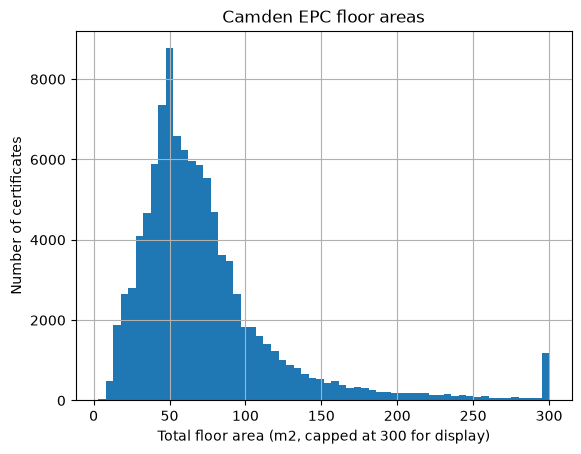

In [18]:
import matplotlib.pyplot as plt

tiny = (df["total_floor_area"] < 10).sum()
huge = (df["total_floor_area"] > 500).sum()
print(f"Under 10 m2 (implausibly small): {tiny}")
print(f"Over 500 m2 (implausibly large for a dwelling): {huge}")

df["total_floor_area"].clip(upper=300).hist(bins=60)
plt.xlabel("Total floor area (m2, capped at 300 for display)")
plt.ylabel("Number of certificates")
plt.title("Camden EPC floor areas")
plt.show()

In [19]:
extremes = df[(df["total_floor_area"] < 10) | (df["total_floor_area"] > 500)]
extremes[["address", "postcode", "total_floor_area", "property_type",
          "built_form", "number_habitable_rooms", "current_energy_rating",
          "lodgement_date"]].sort_values("total_floor_area").head(15)

,address,postcode,total_floor_area,property_type,built_form,number_habitable_rooms,current_energy_rating,lodgement_date
73212,"Flat 2, 307 Kentish Town Road",NW5 2TJ,3,Flat,Mid-Terrace,2.0,C,2022-03-10
11739,"Flat 10, 15, Belsize Avenue",NW3 4BL,5,Flat,Mid-Terrace,2.0,D,2020-08-24
78957,"47d, Talacre Road",NW5 3PJ,5,Flat,End-Terrace,3.0,D,2019-11-06
27232,"Flat 91, Hillsborough Court, Mortimer Crescent",NW6 5NT,5,Flat,Enclosed Mid-Terrace,3.0,D,2024-07-18
24333,"Room 26, 2 Grafton PLace",NW1 1DT,6,Flat,Semi-Detached,1.0,E,2024-10-02
22628,"Flat D, 123 Fortess Road",NW5 2HR,6,Flat,Not Recorded,2.0,D,2025-10-10
18965,"Room 36, 2 Grafton Place",NW1 1DT,6,Flat,Semi-Detached,1.0,E,2024-10-02
9905,"Room 24, 2 Grafton Place",NW1 1DT,6,Flat,Semi-Detached,1.0,E,2024-10-01
31308,"Flat 3, 1 Elm Terrace, Constantine Road",NW3 2LL,6,Flat,Semi-Detached,3.0,C,2025-02-19
37711,"Room 17, 2 Grafton Place",NW1 1DT,6,Flat,Semi-Detached,1.0,E,2024-10-02


In [20]:
contradiction = df[(df["total_floor_area"] < 10) & (df["number_habitable_rooms"] >= 2)]
print(f"Under 10 m2 AND 2+ habitable rooms (internally contradictory): {len(contradiction)}")

per_room = df["total_floor_area"] / df["number_habitable_rooms"]
below_min_room_size = (per_room < 6.5).sum()
print(f"Records implying under 6.5 m2 per habitable room (legal HMO minimum for one bedroom): {below_min_room_size}")

Under 10 m2 AND 2+ habitable rooms (internally contradictory): 12
Records implying under 6.5 m2 per habitable room (legal HMO minimum for one bedroom): 57


In [21]:
giants = df[df["total_floor_area"] > 500]
giants[["address", "postcode", "total_floor_area", "property_type", "built_form",
        "number_habitable_rooms", "current_energy_rating", "lodgement_date"]].sort_values(
        "total_floor_area", ascending=False).head(15)

,address,postcode,total_floor_area,property_type,built_form,number_habitable_rooms,current_energy_rating,lodgement_date
5201,"1, Radlett Place",NW8 6BT,3337,House,Detached,NaN,B,2017-04-13
4083,"Athlone House, Hampstead Lane",N6 4RU,2406,House,Detached,NaN,C,2020-01-16
59613,"Heath Park, North End Way",NW3 7ET,2338,House,Detached,NaN,A,2019-02-08
23813,"Annexe, Heath House, North End Way",NW3 7ET,2338,House,Detached,NaN,A,2019-03-27
28023,"Heath Park, North End Way",NW3 7ET,2338,House,Detached,NaN,A,2019-02-08
59609,"87, Avenue Road",NW8 6JD,2259,House,Detached,NaN,B,2018-08-21
42518,39 Fitzjohns Avenue,NW3 5JT,2232,House,Detached,37.0,D,2015-04-28
48158,40 Avenue Road,NW8 6HS,2213,House,Detached,16.0,D,2024-11-11
5092,83 Endell Street,WC2H 9DN,2194,House,Semi-Detached,66.0,D,2026-05-30
54548,23 West Heath Road,NW3 7UU,2171,House,Detached,19.0,D,2026-05-16


In [22]:
giants_check = giants[["address", "total_floor_area"]].copy()
giants_check["if_sqft_typed_as_m2"] = (giants_check["total_floor_area"] / 10.764).round(0)
giants_check.sort_values("total_floor_area", ascending=False).head(10)

,address,total_floor_area,if_sqft_typed_as_m2
5201,"1, Radlett Place",3337,310.0
4083,"Athlone House, Hampstead Lane",2406,224.0
59613,"Heath Park, North End Way",2338,217.0
23813,"Annexe, Heath House, North End Way",2338,217.0
28023,"Heath Park, North End Way",2338,217.0
59609,"87, Avenue Road",2259,210.0
42518,39 Fitzjohns Avenue,2232,207.0
48158,40 Avenue Road,2213,206.0
5092,83 Endell Street,2194,204.0
54548,23 West Heath Road,2171,202.0


In [23]:
for col in ["co2_emissions_current", "energy_consumption_current",
            "co2_emiss_curr_per_floor_area"]:
    zeros = (df[col] == 0).sum()
    negatives = (df[col] < 0).sum()
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, zeros={zeros}, negatives={negatives}")

co2_emissions_current: min=-1.7, max=164.1, zeros=29, negatives=27
energy_consumption_current: min=-198.0, max=3480.0, zeros=4, negatives=37
co2_emiss_curr_per_floor_area: min=-33.0, max=346.0, zeros=7, negatives=36


In [24]:
neg = df[df["co2_emissions_current"] < 0]
neg[["address", "co2_emissions_current", "energy_consumption_current",
     "photo_supply", "solar_water_heating_flag", "current_energy_rating",
     "total_floor_area", "lodgement_date"]].head(10)

,address,co2_emissions_current,energy_consumption_current,photo_supply,solar_water_heating_flag,current_energy_rating,total_floor_area,lodgement_date
1248,"Flat 2, Marquis Court, 20 Marquis Road",-1.7,-198.0,NaN,NaN,B,51,2022-09-26
2501,"Flat 5, 46 Gray's Inn Road",-0.2,-34.0,NaN,Y,A,32,2012-05-15
2553,"Flat 3, Marquis Court, 20 Marquis Road",-1.6,-193.0,NaN,NaN,B,51,2022-09-26
3559,50 Talacre Road,-0.5,-44.0,NaN,N,C,67,2023-08-17
11902,"Flat 16, 28 Agar Grove",-0.1,-6.0,NaN,NaN,B,92,2024-05-23
12461,"Flat 12, 4 Grafton Yard",-0.9,-65.0,NaN,N,A,96,2024-08-27
15971,"Flat 7, Marquis Court, 20 Marquis Road",-1.3,-94.0,NaN,NaN,B,87,2022-09-26
21058,"Flat 4, Marquis Court, 20 Marquis Road",-1.3,-86.0,NaN,NaN,B,94,2022-09-26
27390,"Flat 5, Marquis Court, 20 Marquis Road",-1.2,-70.0,NaN,NaN,B,104,2022-09-26
35959,"Flat 20, 28 Agar Grove",-0.1,-5.0,NaN,NaN,B,92,2024-05-02


In [25]:
dates = df[["inspection_date", "lodgement_date"]].apply(pd.to_datetime)
future = (dates["lodgement_date"] > "2026-07-16").sum()
backwards = (dates["lodgement_date"] < dates["inspection_date"]).sum()
gap_days = (dates["lodgement_date"] - dates["inspection_date"]).dt.days
print(f"Lodged in the future: {future}")
print(f"Lodged BEFORE inspection (impossible): {backwards}")
print(f"Largest inspection-to-lodgement gap: {gap_days.max()} days")
print(f"Gaps over 1 year: {(gap_days > 365).sum()}")

Lodged in the future: 0
Lodged BEFORE inspection (impossible): 1100
Largest inspection-to-lodgement gap: 545 days
Gaps over 1 year: 283


In [26]:
neg_gaps = gap_days[gap_days < 0]
print(neg_gaps.describe())
print(f"\nExactly -1 day: {(neg_gaps == -1).sum()}")
print(f"Worse than -30 days: {(neg_gaps < -30).sum()}")

count    1100.000000
mean      -87.974545
std         4.917637
min       -90.000000
25%       -90.000000
50%       -89.000000
75%       -88.000000
max       -22.000000
dtype: float64

Exactly -1 day: 0
Worse than -30 days: 1097


In [27]:
impossible_dates = df[gap_days < 0]
impossible_dates["lodgement_date"].str[:4].value_counts().sort_index()

lodgement_date
2012    446
2013    462
2014    192
Name: count, dtype: int64

### Findings: validity

Some register-level validation clearly works: certificate numbers are unique,
no lodgement dates are in the future, and core fields are near-complete. But
value-level validation is largely absent, and each field family we tested
contains physically impossible records.

**Floor areas have no plausibility bounds in either direction.**

- **82 certificates record dwellings under 10 m2** (minimum: a 3 m2 "flat",
  smaller than a prison cell). Within these, **12 records are internally
  contradictory**, claiming 2+ habitable rooms in under 10 m2, and **57 records
  imply less than 6.5 m2 per habitable room**, the legal minimum bedroom size
  for an adult in an HMO (House in Multiple Occupation). Inspection shows two
  distinct causes mixed together: probable entry errors, and single rooms of
  shared houses certificated as if they were whole dwellings (one block
  contributed 8+ "6 m2 flats", one per room, on two days in October 2024).
- **306 certificates exceed 500 m2**, topping out at **3,337 m2**, half a
  football pitch recorded as one house. Some are plausibly genuine (Camden
  contains some of London's largest homes); at least one is a misclassified
  non-domestic building (an adult education centre recorded as a detached
  house); and the most extreme values are arithmetically consistent with
  square feet entered into the square-metre field (3,337 sq ft = a credible
  310 m2 house), a mechanism the data alone cannot confirm. Notably, the
  largest claimed dwellings often lack corroborating fields (habitable room
  counts missing).

**Emissions and energy values go below physical limits.**

- **27 records carry negative current CO2 emissions** (minimum -1.7 t/year),
  **37 negative energy consumption** (minimum -198 kWh/m2), and 29-36 exact
  zeros across these fields. Negative values can be legitimate for homes
  exporting renewable energy, but these records carry no supporting evidence:
  photo_supply (solar PV) is empty throughout, and one record explicitly
  states no solar water heating alongside negative emissions. The specimens
  cluster by building and lodgement day (five from one Kentish Town block,
  same date), pointing to systematic calculation causes rather than typos.

**1,100 certificates were lodged before their inspection took place.**

- Just over 1% of the register records an effect preceding its cause. The
  anatomy is striking: the backwards gaps cluster tightly at **88-90 days**,
  with a hard edge at exactly -90 and not a single -1 day case, and **every
  one of the 1,100 records was lodged in 2012-2014**, after which the
  phenomenon stops completely. This fingerprint is consistent with a batch
  process, migration, or default-value rule from a specific system era, not
  with human scheduling or random error. The affected records remain in the
  published data, uncorrected and unflagged, over a decade later.
- Separately, **283 certificates took more than a year** between inspection
  and lodgement (maximum 545 days), long enough for the property described
  to have changed materially.

Thresholds used above (10 m2, 500 m2, 6.5 m2/room) are audit judgement calls,
stated so they can be challenged; the 6.5 m2 figure is the statutory HMO
minimum for one adult. Counts are floors: only fields tested are reported.

## 5. Consistency: fields that must agree

### Energy rating letter vs efficiency score

The rating letter should be derived from the numeric score by fixed SAP bands
(A: 92+, B: 81-91, C: 69-80, D: 55-68, E: 39-54, F: 21-38, G: 1-20; per the
government's Standard Assessment Procedure). We first validate the rule
against the data, then count violations.

In [28]:
def band(score):
    if score >= 92: return "A"
    if score >= 81: return "B"
    if score >= 69: return "C"
    if score >= 55: return "D"
    if score >= 39: return "E"
    if score >= 21: return "F"
    return "G"

expected = df["current_energy_efficiency"].apply(band)
match = (expected == df["current_energy_rating"])
print(f"Records where letter matches score band: {match.sum()} ({match.mean()*100:.2f}%)")
print(f"Mismatches: {(~match).sum()}")

Records where letter matches score band: 102185 (100.00%)
Mismatches: 0


### Category fields: uncontrolled vocabulary

transaction_type should be a fixed list of categories. We count the distinct
values before and after basic text cleaning, then inspect the differences.

In [29]:
tt = df["transaction_type"].value_counts()
print(f"Distinct transaction_type values: {len(tt)}")

tt_clean = df["transaction_type"].str.lower().str.strip()
print(f"After lowercasing: {tt_clean.nunique()}")

Distinct transaction_type values: 20
After lowercasing: 18


In [30]:
comparison = pd.DataFrame({
    "original_values": df.groupby(tt_clean)["transaction_type"].unique(),
    "count": tt_clean.value_counts()
})
comparison

,original_values,count
transaction_type,,
assessment for green deal,[Assessment for Green Deal],1378
eco assessment,[ECO assessment],942
fit application,[FiT application],91
following green deal,[Following Green Deal],54
grant scheme,[Grant scheme],64
marketed sale,"[Marketed sale, marketed sale]",26585
new dwelling,"[New dwelling, new dwelling]",10960
non marketed sale,[non marketed sale],53
non-grant scheme,[Non-grant scheme],11


In [31]:
rentals = df[tt_clean.isin(["rental", "rental (private)", "rental (social)"])]
pd.crosstab(rentals["lodgement_date"].str[:4], tt_clean[rentals.index])

transaction_type,rental,rental (private),rental (social)
lodgement_date,,,
2012,735,1399,454
2013,3607,0,0
2014,2453,0,0
2015,2772,0,0
2016,2829,0,0
2017,3108,0,0
2018,3885,0,0
2019,5502,0,0
2020,4697,0,0


In [32]:
df["construction_age_band"].value_counts(dropna=False).head(15)

construction_age_band
England and Wales: 1900-1929       26532
England and Wales: before 1900     21094
England and Wales: 1930-1949       11662
England and Wales: 1950-1966        8410
England and Wales: 1967-1975        7678
England and Wales: 1976-1982        3514
England and Wales: 1983-1990        2290
England and Wales: 1996-2002        1995
England and Wales: 2003-2006        1928
England and Wales: 2007-2011        1800
England and Wales: 1991-1995        1375
England and Wales: 2012 onwards     1273
2017                                1135
2014                                1032
2015                                1009
Name: count, dtype: int64

### Findings: consistency

The strongest result in this audit is a positive one: the energy rating
letter matches its numeric score in **all 102,185 records, without a single
exception** (bands per the government's SAP methodology). This shows the
letter is machine-derived from the score. It also proves the register CAN
enforce rules perfectly. The invalid values found in section 4 are therefore
not unavoidable noise: they exist where no rule was applied.

Where no controlled list is enforced, the same category appears in several
forms:

- **transaction_type has 20 distinct values, but only 18 after lowercasing.**
  Two categories exist twice purely due to capital letters: "Marketed sale" /
  "marketed sale" and "New dwelling" / "new dwelling". A filter on one
  spelling silently drops records.
- Lowercasing is not enough: "non marketed sale" (53 records) and
  "non-marketed sale" (1,761) remain separate values, split by a hyphen.
  Text cleaning has layers, and each layer hides records from the last.
- The 18 cleaned values were reviewed manually for misspellings: none found.
  The pattern (consistent spelling, casing and punctuation differences)
  suggests the values come from software dropdown lists that changed between
  versions, rather than free typing.
- **The rental categories tell a downgrade story**: "rental (private)" and
  "rental (social)" were used only in 2012, then disappear; from 2013 onward
  every rental is plain "rental". The register lost the ability to
  distinguish private from social rentals. This matters because minimum
  energy standards apply specifically to private rentals: for 2013-2026,
  roughly 50,000 Camden rental certificates cannot be assigned to the group
  the law targets. (Observed in this extract; likely register-wide, to be
  confirmed against a second borough.)
  **Correction: this conclusion is withdrawn. See Section 7. The tenure column
  keeps the private and social distinction across the whole period, so the
  register did not lose it. Only transaction_type did.**
- **construction_age_band mixes two formats in one column**: descriptive
  bands ("England and Wales: 1900-1929") for older stock and bare years
  ("2017") for newer buildings. Any use of this column, including the
  rebuild detection suggested in section 3, first requires translating both
  formats into one.

Address text is also uncontrolled (seen throughout sections 3 and 4:
"PLace" typos, all-caps addresses, comma variations), which is what makes
address matching unreliable and the missing UPRNs costly.

## 6. Summary of findings

This audit profiled 102,185 domestic Energy Performance Certificates for
Camden (2012-2026) across four data quality dimensions.

**What works well:** certificate numbers are unique, core fields (postcode,
dates, floor area, rating) are near-complete, no future-dated records exist,
and the rating letter matches its score in 100% of records, proof that the
register enforces rules perfectly where rules exist.

**The main findings:**

1. **9.1% of certificates (~9,300) have no UPRN**, the unique property
   identifier, and cannot be reliably linked to a home. (Completeness)
2. **Certificates are not properties**: 92,883 certificates describe 71,513
   properties; 1 in 4 is a repeat visit. One UPRN covers 69 different flats
   in one building, so even property counts by UPRN are wrong. (Uniqueness)
3. **475 certificates are same-day duplicate lodgements**, including one
   flat certificated five times in one day, all copies identical.
   (Uniqueness)
4. **The register has no lifecycle status**: one rebuilt Hampstead building
   holds two generations of contradictory records at the same addresses,
   with nothing linking or superseding them. (Uniqueness)
5. **Impossible values pass validation**: 3 m2 dwellings, homes claiming 2+
   rooms in under 10 m2, negative CO2 emissions with no renewables recorded,
   and 3,337 m2 recorded as one house. (Validity)
6. **1,100 certificates were lodged before their inspection**, all in
   2012-2014, clustered at exactly 88-90 days backwards: the fingerprint of
   a systematic process error, still uncorrected in the published data.
   (Validity)
7. **Category fields drift over time**: casing and punctuation split
   categories, two formats share one column, and the private/social rental
   distinction was lost after 2012, blinding the data to the exact group
   minimum energy standards target. (Consistency)
   **Correction to finding 7: the distinction was lost only in transaction_type, not
   in the register. See Section 7.**

**The pattern across all findings:** where the register enforces a rule, it
holds without exception; where it does not, physically impossible and
contradictory records enter and remain, unflagged, for over a decade. The
cost lands downstream, on anyone using this data for enforcement, research,
or net zero planning.

Next steps: a severity-rated quality report, a cleaning pipeline for the
fixable issues, and analysis of the cleaned data. Findings will be shared
with the register team at MHCLG.

## 7. Correction: the rental distinction was not lost

Section 5 concluded that the register lost the ability to distinguish private from
social rentals after 2012. That conclusion is wrong and is corrected here.

The observation behind it holds: transaction_type does drop the "rental (private)"
and "rental (social)" values after 2012, and every rental is recorded as plain
"rental" from 2013 onward. What was not checked is whether the information survived
in another column. It did.

The tenure column, profiled in Section 2 of this notebook, carries the same
distinction and keeps it across every year of the extract. The two facts sat three
sections apart in this notebook and were never compared.

In [33]:
tenure_clean = df["tenure"].str.lower().str.strip()
insp_year = pd.to_datetime(df["inspection_date"], errors="coerce").dt.year

pd.crosstab(insp_year, tenure_clean)

tenure,owner-occupied,rented (private),rented (social),unknown
inspection_date,,,,
2012,440,462,241,105
2013,2534,2512,1935,584
2014,2198,1664,1508,492
2015,1928,1682,1931,787
2016,1710,1680,1176,972
2017,1962,1565,2070,1167
2018,2065,3030,1765,794
2019,2097,4170,1204,857
2020,2354,3805,820,578


rented (private) appears in every year from 2012 to 2026, so the register can identify
privately rented homes. The finding as originally stated is withdrawn.

What remains is a completeness problem rather than a lost distinction: tenure is
recorded as unknown or left blank on 14.2% of certificates, so the law's applicability
cannot be determined for those properties. transaction_type still shows genuine
vocabulary drift, but the drift no longer carries the regulatory consequence attributed
to it.